In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Create a small dataset (customer data: Age and Annual Income)
data = {
    'Age': [25, 30, 35, 40, 45, 50, 55, 60, 65, 70,
            22, 28, 33, 38, 42, 48, 52, 58, 62, 68],
    'Annual_Income': [30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000,
                      25000, 32000, 38000, 42000, 48000, 52000, 58000, 62000, 68000, 72000]
}

df = pd.DataFrame(data)
print("Dataset:")
print(df.head(10))
print(f"\nDataset shape: {df.shape}")

Dataset:
   Age  Annual_Income
0   25          30000
1   30          35000
2   35          40000
3   40          45000
4   45          50000
5   50          55000
6   55          60000
7   60          65000
8   65          70000
9   70          75000

Dataset shape: (20, 2)


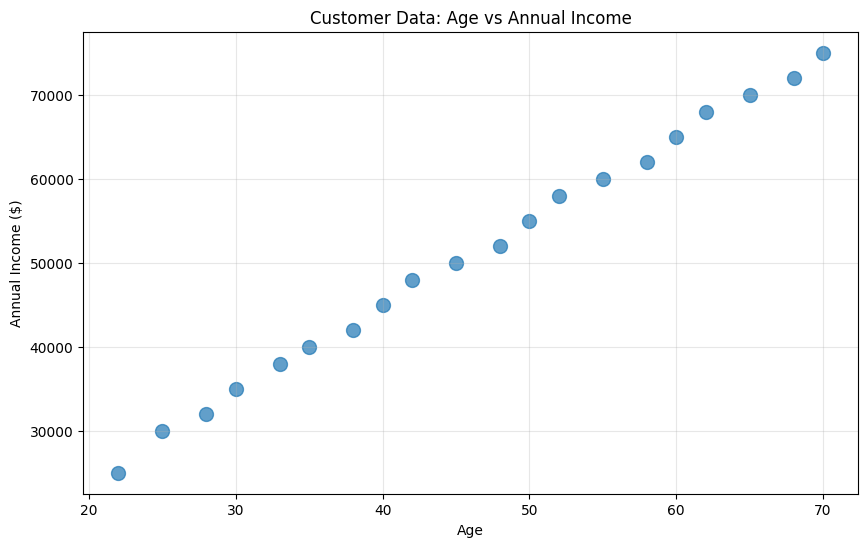

In [2]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Annual_Income'], s=100, alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Annual Income ($)')
plt.title('Customer Data: Age vs Annual Income')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# Standardize features (important for K-means)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_data, columns=['Age', 'Annual_Income'])

print("Scaled Data (first 5 rows):")
print(df_scaled.head())

Scaled Data (first 5 rows):
        Age  Annual_Income
0 -1.477564      -1.442063
1 -1.130718      -1.100342
2 -0.783872      -0.758621
3 -0.437026      -0.416900
4 -0.090180      -0.075179


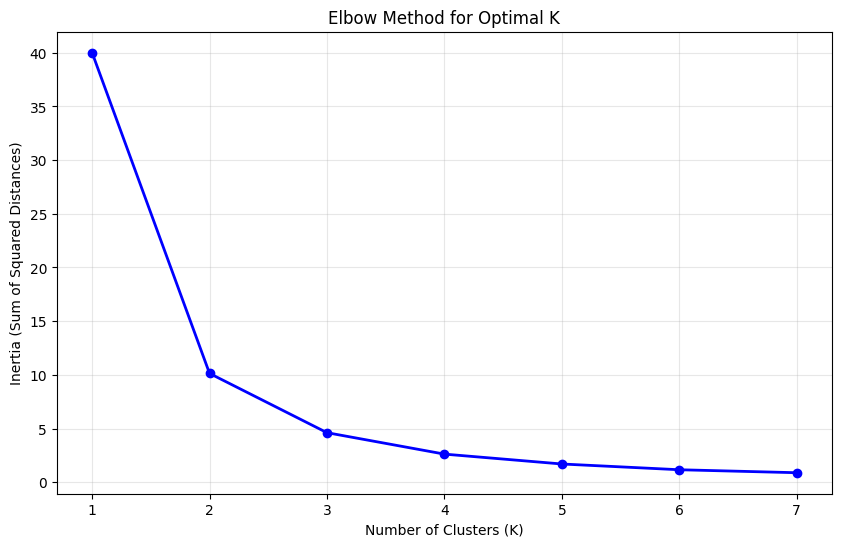

In [4]:
# Elbow method to find optimal K
inertias = []
K_range = range(1, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

In [5]:
# Choose K=3 (from elbow method)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# Get cluster centers (in original scale)
cluster_centers_scaled = kmeans.cluster_centers_
cluster_centers = scaler.inverse_transform(cluster_centers_scaled)

print("Cluster Centers (Original Scale):")
print(pd.DataFrame(cluster_centers, columns=['Age', 'Annual_Income']))
print("\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

Cluster Centers (Original Scale):
         Age  Annual_Income
0  62.571429   67428.571429
1  28.833333   33333.333333
2  45.000000   50000.000000

Cluster Distribution:
Cluster
0    7
1    6
2    7
Name: count, dtype: int64


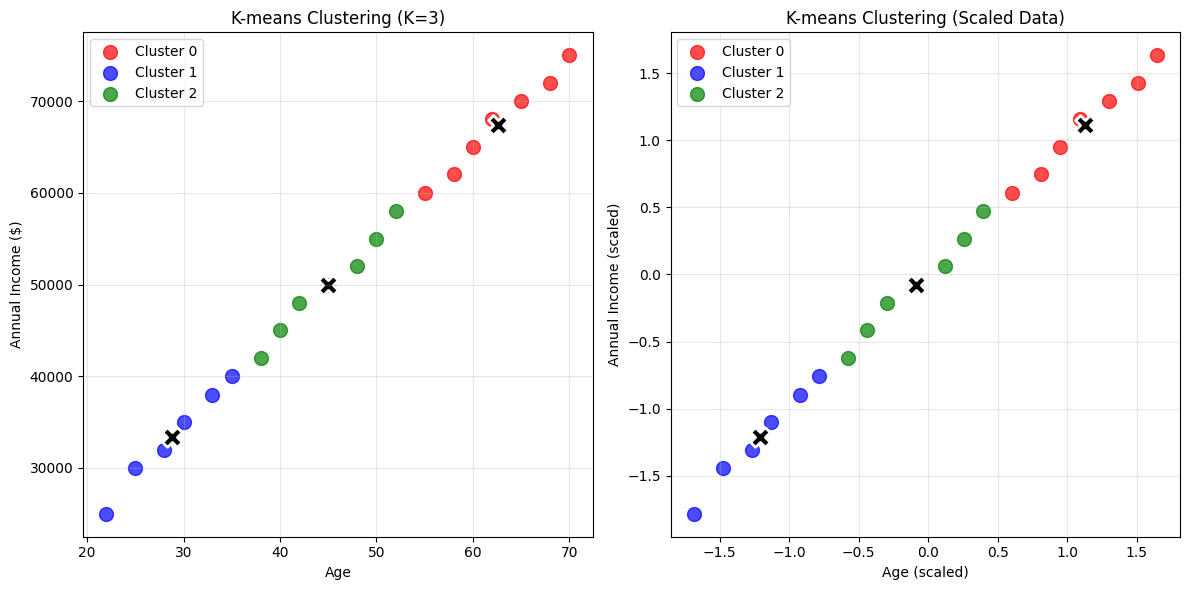

In [6]:
# Plot clusters
plt.figure(figsize=(12, 6))

# Subplot 1: Original data with clusters
plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green']
for cluster in range(3):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Age'], cluster_data['Annual_Income'],
               c=colors[cluster], label=f'Cluster {cluster}', s=100, alpha=0.7)

    # Plot cluster centers
    plt.scatter(cluster_centers[cluster][0], cluster_centers[cluster][1],
               c='black', marker='X', s=200, linewidths=2,
               edgecolors='white')

plt.xlabel('Age')
plt.ylabel('Annual Income ($)')
plt.title('K-means Clustering (K=3)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Scaled data
plt.subplot(1, 2, 2)
for cluster in range(3):
    cluster_data = df_scaled[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Age'], cluster_data['Annual_Income'],
               c=colors[cluster], label=f'Cluster {cluster}', s=100, alpha=0.7)

    # Plot cluster centers (scaled)
    plt.scatter(cluster_centers_scaled[cluster][0], cluster_centers_scaled[cluster][1],
               c='black', marker='X', s=200, linewidths=2,
               edgecolors='white')

plt.xlabel('Age (scaled)')
plt.ylabel('Annual Income (scaled)')
plt.title('K-means Clustering (Scaled Data)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Analyze cluster characteristics
print("Cluster Analysis:")
print("="*50)

for cluster in range(3):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\nCluster {cluster}:")
    print(f"  Count: {len(cluster_data)} customers")
    print(f"  Average Age: {cluster_data['Age'].mean():.1f} years")
    print(f"  Average Income: ${cluster_data['Annual_Income'].mean():,.0f}")
    print(f"  Age Range: {cluster_data['Age'].min():.0f} - {cluster_data['Age'].max():.0f}")
    print(f"  Income Range: ${cluster_data['Annual_Income'].min():,.0f} - ${cluster_data['Annual_Income'].max():,.0f}")

Cluster Analysis:

Cluster 0:
  Count: 7 customers
  Average Age: 62.6 years
  Average Income: $67,429
  Age Range: 55 - 70
  Income Range: $60,000 - $75,000

Cluster 1:
  Count: 6 customers
  Average Age: 28.8 years
  Average Income: $33,333
  Age Range: 22 - 35
  Income Range: $25,000 - $40,000

Cluster 2:
  Count: 7 customers
  Average Age: 45.0 years
  Average Income: $50,000
  Age Range: 38 - 52
  Income Range: $42,000 - $58,000


In [8]:
# Print complete dataset with cluster assignments
print("\nComplete Dataset with Clusters:")
print(df.sort_values('Cluster'))

# Summary statistics by cluster
summary = df.groupby('Cluster').agg({
    'Age': ['count', 'mean', 'min', 'max'],
    'Annual_Income': ['mean', 'min', 'max']
}).round(1)

print("\nCluster Summary Statistics:")
print(summary)


Complete Dataset with Clusters:
    Age  Annual_Income  Cluster
6    55          60000        0
7    60          65000        0
9    70          75000        0
8    65          70000        0
18   62          68000        0
19   68          72000        0
17   58          62000        0
2    35          40000        1
12   33          38000        1
11   28          32000        1
0    25          30000        1
1    30          35000        1
10   22          25000        1
4    45          50000        2
3    40          45000        2
5    50          55000        2
15   48          52000        2
14   42          48000        2
13   38          42000        2
16   52          58000        2

Cluster Summary Statistics:
          Age               Annual_Income              
        count  mean min max          mean    min    max
Cluster                                                
0           7  62.6  55  70       67428.6  60000  75000
1           6  28.8  22  35       33333.3 